# 👩‍💻 Simulate a Convolution Operation with NumPy and Visualize Filters

## 📋 Overview
In this lab, you'll manually implement convolution operations on images using NumPy - a fundamental concept in Convolutional Neural Networks (CNNs). By performing these operations step by step, you'll gain intuition about how CNNs detect features in images. This skill is essential for computer vision applications in fields like autonomous driving, medical image analysis, and facial recognition systems.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Load and manipulate image data using NumPy and Matplotlib
- Implement a manual 2D convolution operation using nested loops
- Apply different types of filters to detect specific image features
- Implement and understand the effects of max pooling on feature maps

## 🚀 Starting Point
Access the starter code below to get started with your lab:

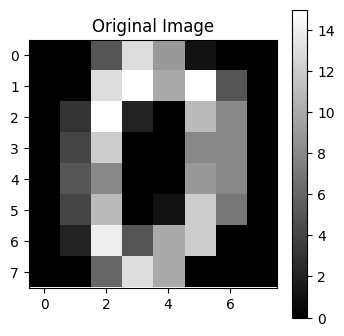

In [1]:
# Starter code
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Load a sample digit image from sklearn
digits = load_digits()
image = digits.images[0]  # Get the first digit image (8x8 grayscale)

# Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.colorbar()
plt.show()

# You'll build the convolution and pooling operations in the tasks below

Required tools/setup:

- Python 3.x
- NumPy
- Matplotlib
- scikit-learn (for sample images)

Make sure you understand basic NumPy operations like array slicing and element-wise multiplication.

## Task 1: Implement a Manual 2D Convolution Function
**Context:** In computer vision systems, convolution is used to detect features like edges, textures, and shapes. Self-driving cars use these operations to identify lane markings and obstacles.

**Steps:**

1. Create a function that accepts an image and a filter (kernel) as input
2. Initialize an output array with the appropriate dimensions
3. Implement nested loops to slide the filter over the image
4. At each position, compute the element-wise multiplication and sum
5. Return the resulting feature map

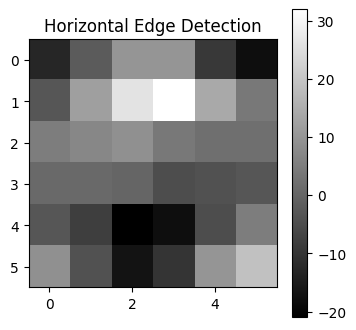

In [2]:
# Task 1: Manual 2D convolution implementation
# Your code will go here

def apply_convolution(image, kernel):
    # Get dimensions
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate output dimensions
    out_height = img_height - kernel_height + 1
    out_width = img_width - kernel_width + 1
    
    # Initialize output feature map
    output = np.zeros((out_height, out_width))
    
    # Perform convolution
    for i in range(out_height):
        for j in range(out_width):
            # Extract the current window
            window = image[i:i+kernel_height, j:j+kernel_width]
            # Apply the filter (element-wise multiply and sum)
            output[i, j] = np.sum(window * kernel)
            
    return output

# Define a horizontal edge detection filter
horizontal_edge_filter = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])

# Apply the filter and display the result
horizontal_edges = apply_convolution(image, horizontal_edge_filter)
plt.figure(figsize=(4, 4))
plt.imshow(horizontal_edges, cmap='gray')
plt.title('Horizontal Edge Detection')
plt.colorbar()
plt.show()

**💡 Tip:** Consider using NumPy's `np.zeros()` to initialize your output array and `np.sum()` for the dot product calculation.

**⚙️ Test Your Work:**

- Create a simple 3x3 horizontal edge detection filter
- Apply your convolution function to the sample image
- Display the resulting feature map using `plt.imshow()`
- You should see horizontal edges highlighted in the output

## Task 2: Experiment with Different Convolution Filters
**Context:** Different convolution filters detect different features. In medical imaging, specialized filters help detect tumors or anomalies by highlighting specific patterns.

**Steps:**
1. Create at least three different 3×3 filters:
    - A vertical edge detection filter
    - A sharpening filter
    - A blur filter (box or Gaussian)
2. Apply each filter to your image using your convolution function
3. Display the original and filtered images side by side
4. Analyze how each filter transforms the image

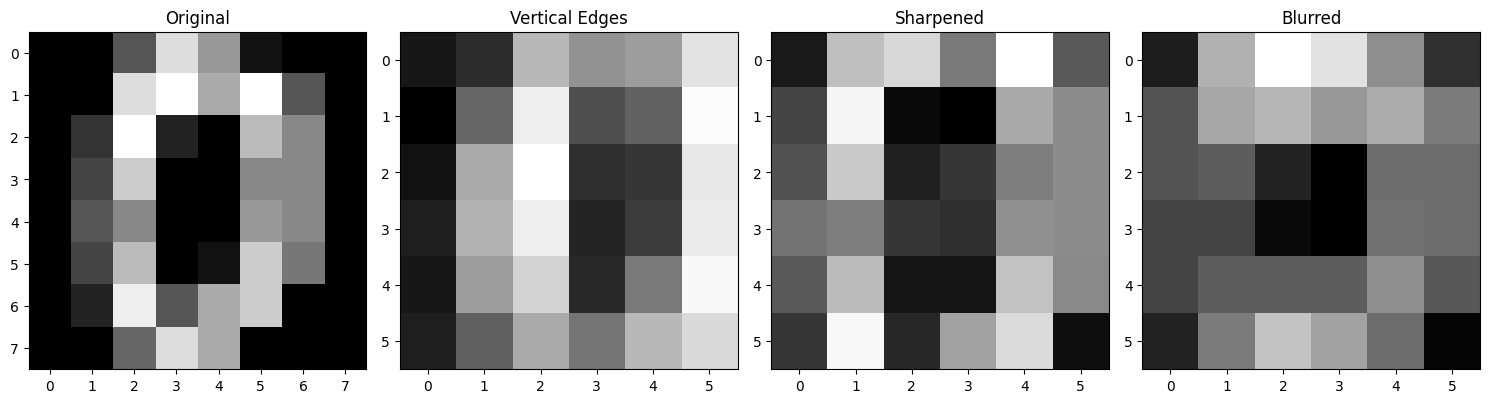

In [3]:
# Task 2: Implement different filters
# Your code will go here

vertical_edge_filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# Sharpening filter
sharpen_filter = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Blur filter (box blur)
blur_filter = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

# Apply filters
vertical_edges = apply_convolution(image, vertical_edge_filter)
sharpened = apply_convolution(image, sharpen_filter)
blurred = apply_convolution(image, blur_filter)

# Display results side by side
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')

plt.subplot(1, 4, 2)
plt.imshow(vertical_edges, cmap='gray')
plt.title('Vertical Edges')

plt.subplot(1, 4, 3)
plt.imshow(sharpened, cmap='gray')
plt.title('Sharpened')

plt.subplot(1, 4, 4)
plt.imshow(blurred, cmap='gray')
plt.title('Blurred')

plt.tight_layout()
plt.show()

**💡 Tip:** Use `plt.subplot()` to display multiple images in a single figure for comparison.

**⚙️ Test Your Work:**

- Each filter should produce visually different results
- Edge detection filters should highlight edges
- Blurring filter should make the image smoother

## Task 3: Implement Max Pooling
**Context:** Pooling operations reduce the spatial dimensions of feature maps in CNNs, making networks more computationally efficient and robust to small variations. Image recognition systems use pooling to identify objects regardless of their exact position.

**Steps:**

1. Create a function that implements a max pooling operation
2. Define a pool size parameter (typically 2×2)
3. Stride through the input image with the chosen pool size
4. For each window, select the maximum value
5. Return the reduced feature map
6. Compare the original and pooled images

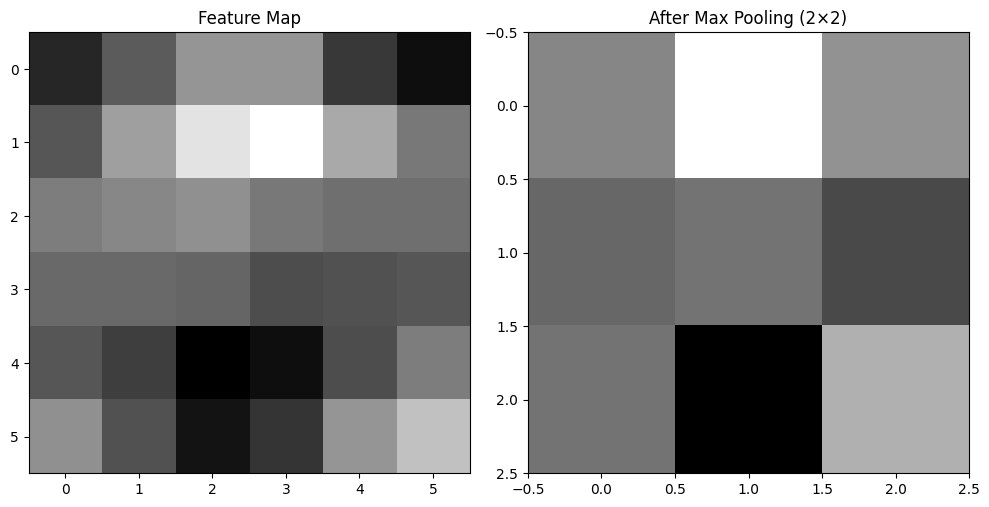

In [4]:
# Task 3: Max pooling implementation
# Your code will go here

def max_pooling(feature_map, pool_size=2):
    # Get dimensions
    height, width = feature_map.shape
    
    # Calculate output dimensions
    out_height = height // pool_size
    out_width = width // pool_size
    
    # Initialize output
    output = np.zeros((out_height, out_width))
    
    # Perform max pooling
    for i in range(out_height):
        for j in range(out_width):
            # Extract current window and find maximum
            window = feature_map[i*pool_size:(i+1)*pool_size, 
                               j*pool_size:(j+1)*pool_size]
            output[i, j] = np.max(window)
    
    return output

# Apply max pooling to one of our feature maps
pooled_edges = max_pooling(horizontal_edges)

# Display original feature map and pooled result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(horizontal_edges, cmap='gray')
plt.title('Feature Map')

plt.subplot(1, 2, 2)
plt.imshow(pooled_edges, cmap='gray')
plt.title('After Max Pooling (2×2)')

plt.tight_layout()
plt.show()

**💡 Tip:** Use integer division (`//`) when calculating the dimensions of the output pooled image.

**⚙️ Test Your Work:**

- Apply max pooling to your convolved feature maps
- The resulting image should be smaller but preserve the important features
- Verify the output size is correct (original dimensions divided by the pool size)

## ✅ Success Checklist
- Your convolution function correctly applies filters to images
- You've successfully implemented and tested at least three different filters
- Your max pooling function correctly reduces image dimensions while preserving features
- You can explain how different filters affect feature detection
- All visualizations clearly show the effects of each operation
- Your code runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Output dimensions are incorrect after convolution **Solution:** Remember that the output dimensions will be smaller than the input. For a filter of size f×f and an input of size n×n, the output will be (n-f+1)×(n-f+1).

**Problem:** Edge effects creating artifacts in the output **Solution:** Consider implementing padding to maintain the original image dimensions.

**Problem:** Max pooling not reducing dimensions correctly **Solution:** Check that you're using the correct stride length and window size in your implementation.

## 🔑 Key Points
- Convolution is a sliding window operation that helps detect features in images
- Different filters detect different types of features (edges, textures, etc.)
- Max pooling reduces spatial dimensions while preserving important features
- These operations form the foundation of convolutional neural networks

## 💻 Reference Solution

<details>    
<summary><strong>Click HERE to see a referance solution</strong></summary>    

```python
# Task 1: Manual 2D convolution implementation
def apply_convolution(image, kernel):
    # Get dimensions
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    
    # Calculate output dimensions
    out_height = img_height - kernel_height + 1
    out_width = img_width - kernel_width + 1
    
    # Initialize output feature map
    output = np.zeros((out_height, out_width))
    
    # Perform convolution
    for i in range(out_height):
        for j in range(out_width):
            # Extract the current window
            window = image[i:i+kernel_height, j:j+kernel_width]
            # Apply the filter (element-wise multiply and sum)
            output[i, j] = np.sum(window * kernel)
            
    return output

# Define a horizontal edge detection filter
horizontal_edge_filter = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])

# Apply the filter and display the result
horizontal_edges = apply_convolution(image, horizontal_edge_filter)
plt.figure(figsize=(4, 4))
plt.imshow(horizontal_edges, cmap='gray')
plt.title('Horizontal Edge Detection')
plt.colorbar()
plt.show()

# Task 2: Experiment with different filters
# Vertical edge detection filter
vertical_edge_filter = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

# Sharpening filter
sharpen_filter = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Blur filter (box blur)
blur_filter = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

# Apply filters
vertical_edges = apply_convolution(image, vertical_edge_filter)
sharpened = apply_convolution(image, sharpen_filter)
blurred = apply_convolution(image, blur_filter)

# Display results side by side
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')

plt.subplot(1, 4, 2)
plt.imshow(vertical_edges, cmap='gray')
plt.title('Vertical Edges')

plt.subplot(1, 4, 3)
plt.imshow(sharpened, cmap='gray')
plt.title('Sharpened')

plt.subplot(1, 4, 4)
plt.imshow(blurred, cmap='gray')
plt.title('Blurred')

plt.tight_layout()
plt.show()

# Task 3: Implement max pooling
def max_pooling(feature_map, pool_size=2):
    # Get dimensions
    height, width = feature_map.shape
    
    # Calculate output dimensions
    out_height = height // pool_size
    out_width = width // pool_size
    
    # Initialize output
    output = np.zeros((out_height, out_width))
    
    # Perform max pooling
    for i in range(out_height):
        for j in range(out_width):
            # Extract current window and find maximum
            window = feature_map[i*pool_size:(i+1)*pool_size, 
                               j*pool_size:(j+1)*pool_size]
            output[i, j] = np.max(window)
    
    return output

# Apply max pooling to one of our feature maps
pooled_edges = max_pooling(horizontal_edges)

# Display original feature map and pooled result
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(horizontal_edges, cmap='gray')
plt.title('Feature Map')

plt.subplot(1, 2, 2)
plt.imshow(pooled_edges, cmap='gray')
plt.title('After Max Pooling (2×2)')

plt.tight_layout()
plt.show()
```